# 🌙 Extracción Multimodal — EEG + EOG + EMG (v2)

**Versión 2 del notebook 1** del pipeline reorientado. Mejora la
versión original añadiendo dos modalidades adicionales que la AASM
considera definitorias para ciertas fases:

| Modalidad | Por qué importa |
|---|---|
| **EEG** | Marcador principal de todas las fases (ya estaba) |
| **EOG** | Define **N1** (movimientos oculares lentos) y **REM** (movimientos rápidos) |
| **EMG** | Define **REM** (atonía muscular completa) |

### Diferencia con el notebook 1 original

El notebook 1 original solo procesaba canales EEG. Las funciones
`es_canal_eog`, `es_canal_emg` filtraban estos canales con
`_NO_EEG_TOKENS` y se descartaban. Aquí los procesamos como
modalidades **separadas**, cada una con sus propias features
específicas para esa señal.

### Output compatible con el resto del pipeline

El CSV resultante tiene exactamente la misma estructura que la versión
original (`caracteristicas_fases_30s.csv`), solo con **más columnas de
features**. Los notebooks 2 (modelado), HMM y de figuras lo consumen
sin cambios.

### Ganancia esperada

| Métrica | v1 (solo EEG) | v2 (EEG+EOG+EMG) esperada |
|---|---|---|
| κ (AASM) | 0.62 | **0.68 – 0.72** |
| Recall N1 | 0.11 | **0.25 – 0.35** |
| Recall REM | 0.65 | **0.75 – 0.82** |

## 1. Importaciones y configuración

Mismas dependencias que el notebook 1 original.

In [3]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal as scipy_signal
from scipy import stats as scipy_stats
from scipy.signal import find_peaks

import mne

warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

plt.rcParams.update({
    'figure.dpi': 110, 'figure.figsize': (13, 5),
    'axes.titlesize': 13, 'axes.labelsize': 11, 'font.size': 10,
})
sns.set_style('whitegrid')

_trapz = getattr(np, 'trapezoid', None) or np.trapz

# ── Rutas ──
UPLOADS_DIR = Path.cwd() / '../data/cap-sleep-database'
HYPNO_DIR      = Path.cwd() / '../data/hypnograms'
FEATURES_DIR   = Path.cwd() / '../data/features_fases'
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
EDF_DIR        = UPLOADS_DIR

# ── Parámetros (idénticos al notebook 1) ──
TARGET_FS      = 256
EPOCH_SECONDS  = 30
EPOCH_SAMPLES  = TARGET_FS * EPOCH_SECONDS

CLASES_RK = ['W', 'S1', 'S2', 'S3', 'S4', 'REM']

# Bandas EEG (con sigma para husos de sueño en S2)
EEG_BANDS = {
    'delta': (0.5, 4.0),
    'theta': (4.0, 8.0),
    'alpha': (8.0, 11.0),
    'sigma': (11.0, 16.0),
    'beta':  (16.0, 30.0),
}

# Bandas específicas para EOG
EOG_BANDS = {
    'slow_eye': (0.5, 2.0),   # movimientos oculares lentos (N1, somnolencia)
    'fast_eye': (2.0, 8.0),   # movimientos rápidos (REM, sacadas)
}

# Canales por modalidad. Reusamos solo el primero de cada tipo
# (cuando hay varios) para mantener el dataset manejable.
MAX_CANALES_EEG = 2
MAX_CANALES_EOG = 2   # si hay LOC y ROC, ambos
MAX_CANALES_EMG = 1   # con CHIN1 o uno solo basta

print(f'Frecuencia objetivo : {TARGET_FS} Hz')
print(f'Época               : {EPOCH_SECONDS} s = {EPOCH_SAMPLES} muestras')
print(f'Bandas EEG          : {list(EEG_BANDS.keys())}')
print(f'Bandas EOG          : {list(EOG_BANDS.keys())}')
print(f'Modalidades         : EEG, EOG, EMG')

Frecuencia objetivo : 256 Hz
Época               : 30 s = 7680 muestras
Bandas EEG          : ['delta', 'theta', 'alpha', 'sigma', 'beta']
Bandas EOG          : ['slow_eye', 'fast_eye']
Modalidades         : EEG, EOG, EMG


## 2. Identificación de canales por modalidad

Tres funciones, una por modalidad. Cada una identifica los canales de
su tipo y descarta los demás.

In [4]:
# Conjuntos de electrodos
_ELECTRODOS_EEG = {'FP1','FP2','F3','F4','F7','F8','FZ','C3','C4','CZ',
                   'P3','P4','PZ','O1','O2','T3','T4','T5','T6','A1','A2'}

# Tokens que NO son ninguna de las 3 modalidades de interés
_DESCARTAR_TOKENS = {'SAO2','SPO2','MIC','FLUSSO','FLOW','TORACE',
                     'ADDOME','ADDDOME','POSITION','HR','PLETH','STAT'}


def es_canal_eeg(nombre):
    '''True solo para derivaciones EEG bipolares 10-20.'''
    u = nombre.upper().replace(' ', '')
    # Excluir explícitamente las otras modalidades
    if any(t in u for t in ['EMG','ECG','EKG','EOG','CHIN','ROC','LOC']):
        return False
    if any(t in u for t in _DESCARTAR_TOKENS):
        return False
    if '-' in u:
        partes = u.split('-')
        return any(p in _ELECTRODOS_EEG for p in partes)
    for k in (2, 3):
        if u[:k] in _ELECTRODOS_EEG and u[k:] in _ELECTRODOS_EEG:
            return True
    return False


def es_canal_eog(nombre):
    '''True para canales EOG (electrooculograma).'''
    u = nombre.upper().replace(' ', '').replace('-', '')
    # ROC = right outer canthus, LOC = left outer canthus
    # EOG-L, EOG-R también son variantes
    return any(t in u for t in ['ROC', 'LOC', 'EOGL', 'EOGR', 'EOG1', 'EOG2'])


def es_canal_emg(nombre):
    '''True para EMG submentoniano (tono muscular).'''
    u = nombre.upper().replace(' ', '').replace('-', '')
    # CHIN1, CHIN2, EMG-SUBMEN, EMG1...
    if any(t in u for t in ['CHIN', 'SUBMEN']):
        return True
    # EMG genérico — pero solo si no es de tibia/extremidad
    if u.startswith('EMG') and not any(t in u for t in ['TIB','LEG','ARM']):
        return True
    return False


def listar_canales_por_modalidad(raw):
    '''Devuelve dict {modalidad: [canales]} para un EDF.'''
    eeg = [c for c in raw.ch_names if es_canal_eeg(c)]
    eog = [c for c in raw.ch_names if es_canal_eog(c)]
    emg = [c for c in raw.ch_names if es_canal_emg(c)]
    return {'eeg': eeg, 'eog': eog, 'emg': emg}


# Demostración con los EDF disponibles
print('Distribución de canales por modalidad:')
print(f'{"Archivo":<15}{"EEG":>8}{"EOG":>8}{"EMG":>8}')
for edf in sorted(EDF_DIR.glob('*.edf')):
    raw = mne.io.read_raw_edf(edf, preload=False, verbose='ERROR')
    mods = listar_canales_por_modalidad(raw)
    print(f'{edf.name:<15}{len(mods["eeg"]):>8}{len(mods["eog"]):>8}'
          f'{len(mods["emg"]):>8}')
    print(f'  EEG: {mods["eeg"][:4]}{"..." if len(mods["eeg"])>4 else ""}')
    print(f'  EOG: {mods["eog"]}')
    print(f'  EMG: {mods["emg"]}')

Distribución de canales por modalidad:
Archivo             EEG     EOG     EMG
brux1.edf            13       1       1
  EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2']...
  EOG: ['ROC-LOC']
  EMG: ['EMG1-EMG2']
brux2.edf            13       1       1
  EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2']...
  EOG: ['ROC-LOC']
  EMG: ['EMG1-EMG2']
ins1.edf              5       1       1
  EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2']...
  EOG: ['ROC-LOC']
  EMG: ['EMG1-EMG2']
ins2.edf              5       1       1
  EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2']...
  EOG: ['ROC-LOC']
  EMG: ['EMG1-EMG2']
ins3.edf              7       1       1
  EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2']...
  EOG: ['ROC-LOC']
  EMG: ['EMG1-EMG2']
ins4.edf              5       1       1
  EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2']...
  EOG: ['ROC-LOC']
  EMG: ['EMG1-EMG2']
ins5.edf              5       1       1
  EEG: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2']...
  EOG: ['ROC-LOC']
  EMG: ['EMG1-EMG2']
ins6.edf              5  

## 3. Extracción de características por modalidad

Cada modalidad necesita features distintas porque captura información
fisiológica distinta:

- **EEG**: ondas cerebrales por bandas (delta, theta, alpha, sigma, beta).
- **EOG**: movimientos oculares lentos vs rápidos, simetría L/R.
- **EMG**: amplitud y energía muscular (alta = vigilia, baja = REM).

In [5]:
# === Features EEG (idénticas al notebook 1 original) ===

def extract_eeg_features(ventana, sfreq=TARGET_FS):
    '''32 características EEG: tiempo, frecuencia, Hjorth, entropía.'''
    x = np.asarray(ventana, dtype=float).ravel()
    if x.size == 0 or np.all(np.isnan(x)):
        # plantilla NaN para que las columnas existan
        plantilla = {}
        plantilla.update({k: np.nan for k in ['media','mediana','std','varianza',
            'rms','energia','maximo','minimo','rango','skewness','kurtosis','zcr']})
        for b in EEG_BANDS:
            plantilla[f'pot_{b}'] = np.nan
            plantilla[f'pot_{b}_rel'] = np.nan
        plantilla.update({'pot_total':np.nan,'freq_dominante':np.nan,
            'freq_mediana':np.nan,'ratio_delta_beta':np.nan,'ratio_slow_fast':np.nan,
            'hjorth_activity':np.nan,'hjorth_mobility':np.nan,'hjorth_complexity':np.nan,
            'entropia_shannon':np.nan,'entropia_espectral':np.nan})
        return plantilla
    
    std = np.std(x)
    feats = {
        'media': np.mean(x), 'mediana': np.median(x), 'std': std,
        'varianza': np.var(x), 'rms': np.sqrt(np.mean(x**2)),
        'energia': np.sum(x**2), 'maximo': np.max(x), 'minimo': np.min(x),
        'rango': np.ptp(x),
        'skewness': scipy_stats.skew(x) if std > 0 else 0.0,
        'kurtosis': scipy_stats.kurtosis(x) if std > 0 else 0.0,
        'zcr': np.mean(np.diff(np.sign(x)) != 0),
    }
    
    # Frecuencia
    nperseg = min(int(sfreq * 2), len(x))
    f, psd = scipy_signal.welch(x, fs=sfreq, nperseg=nperseg,
                                 noverlap=nperseg // 2)
    pot_total = _trapz(psd, f)
    feats['pot_total'] = pot_total
    for nombre, (lo, hi) in EEG_BANDS.items():
        m = (f >= lo) & (f < hi)
        pa = _trapz(psd[m], f[m]) if m.any() else 0.0
        feats[f'pot_{nombre}'] = pa
        feats[f'pot_{nombre}_rel'] = pa / pot_total if pot_total > 0 else 0.0
    feats['freq_dominante'] = f[np.argmax(psd)] if len(psd) else 0.0
    if pot_total > 0:
        df = f[1] - f[0] if len(f) > 1 else 1.0
        cum = np.cumsum(psd) * df
        feats['freq_mediana'] = f[min(np.searchsorted(cum, pot_total/2), len(f)-1)]
    else:
        feats['freq_mediana'] = 0.0
    feats['ratio_delta_beta'] = (feats['pot_delta'] / feats['pot_beta']
                                  if feats['pot_beta'] > 0 else 0.0)
    feats['ratio_slow_fast'] = ((feats['pot_delta'] + feats['pot_theta']) /
                                 (feats['pot_alpha'] + feats['pot_sigma'] + feats['pot_beta'])
                                 if (feats['pot_alpha']+feats['pot_sigma']+feats['pot_beta']) > 0 else 0.0)
    
    # Hjorth
    dx, ddx = np.diff(x), np.diff(np.diff(x))
    vx, vdx, vddx = np.var(x), np.var(dx), np.var(ddx)
    mob = np.sqrt(vdx / vx) if vx > 0 else 0.0
    mob_dx = np.sqrt(vddx / vdx) if vdx > 0 else 0.0
    feats['hjorth_activity'] = vx
    feats['hjorth_mobility'] = mob
    feats['hjorth_complexity'] = mob_dx / mob if mob > 0 else 0.0
    
    # Entropía
    hist, _ = np.histogram(x, bins=16)
    p = hist[hist > 0] / hist.sum()
    feats['entropia_shannon'] = -np.sum(p * np.log2(p)) if p.size else 0.0
    pn = psd / psd.sum() if psd.sum() > 0 else psd
    pn = pn[pn > 0]
    feats['entropia_espectral'] = -np.sum(pn * np.log2(pn)) if pn.size else 0.0
    
    return feats

In [6]:
# === Features EOG (NUEVAS) ===

def extract_eog_features(ventana, sfreq=TARGET_FS):
    '''
    Features de electrooculograma.
    Discriminantes para N1 (movimientos lentos) y REM (movimientos rápidos).
    '''
    x = np.asarray(ventana, dtype=float).ravel()
    
    plantilla = {f'eog_{k}': np.nan for k in 
                 ['rms','std','var_deriv','p2p','zcr',
                  'pot_slow','pot_fast','ratio_slow_fast',
                  'n_picos','pot_total']}
    if x.size == 0 or np.all(np.isnan(x)) or np.std(x) == 0:
        return plantilla
    
    # Estadísticas básicas
    plantilla['eog_rms'] = np.sqrt(np.mean(x**2))
    plantilla['eog_std'] = np.std(x)
    plantilla['eog_var_deriv'] = np.var(np.diff(x))   # captura movimientos bruscos
    plantilla['eog_p2p'] = np.ptp(x)                   # amplitud pico-a-pico
    plantilla['eog_zcr'] = np.mean(np.diff(np.sign(x)) != 0)
    
    # Frecuencial: bandas EOG
    nperseg = min(int(sfreq * 2), len(x))
    f, psd = scipy_signal.welch(x, fs=sfreq, nperseg=nperseg, noverlap=nperseg//2)
    pot_total = _trapz(psd, f)
    plantilla['eog_pot_total'] = pot_total
    for nombre, (lo, hi) in EOG_BANDS.items():
        m = (f >= lo) & (f < hi)
        pa = _trapz(psd[m], f[m]) if m.any() else 0.0
        plantilla[f'eog_pot_{nombre.replace("_eye","")}'] = pa
    # Ratio lento/rápido — característico de N1
    plantilla['eog_ratio_slow_fast'] = (
        plantilla['eog_pot_slow'] / plantilla['eog_pot_fast']
        if plantilla['eog_pot_fast'] > 0 else 0.0
    )
    
    # Conteo de picos (cada sacada ocular es un pico bien definido)
    # Umbral relativo al desvío
    try:
        picos, _ = find_peaks(np.abs(x), height=2*np.std(x),
                              distance=int(sfreq*0.1))
        plantilla['eog_n_picos'] = len(picos)
    except Exception:
        plantilla['eog_n_picos'] = 0
    
    return plantilla


# Test sintético: simular una sacada ocular rápida
t = np.arange(7680) / 256
# Movimiento ocular lento (típico N1)
eog_lento = np.sin(2*np.pi*1*t) * 50 + np.random.randn(7680)*5
# Movimientos rápidos (típico REM)
eog_rapido = np.zeros(7680)
for k in range(10):
    inicio = int(np.random.uniform(0, 7000))
    eog_rapido[inicio:inicio+200] = 100 * np.exp(-np.arange(200)/30)
eog_rapido += np.random.randn(7680)*5

print('Test EOG con dos señales sintéticas:')
fs_test = extract_eog_features(eog_lento)
fr_test = extract_eog_features(eog_rapido)
print(f'  Movimiento LENTO: ratio_slow_fast = {fs_test["eog_ratio_slow_fast"]:.2f} '
      f'(esperado >> 1)')
print(f'  Movimiento RÁPIDO: ratio_slow_fast = {fr_test["eog_ratio_slow_fast"]:.2f} '
      f'(esperado << 1)')
print(f'  N picos en señal rápida: {fr_test["eog_n_picos"]} (esperado ~10)')

Test EOG con dos señales sintéticas:
  Movimiento LENTO: ratio_slow_fast = 975.73 (esperado >> 1)
  Movimiento RÁPIDO: ratio_slow_fast = 1.46 (esperado << 1)
  N picos en señal rápida: 18 (esperado ~10)


In [7]:
# === Features EMG (NUEVAS) ===

def extract_emg_features(ventana, sfreq=TARGET_FS):
    '''
    Features de electromiograma submentoniano.
    Discriminante PRINCIPAL para REM (atonía muscular).
    '''
    x = np.asarray(ventana, dtype=float).ravel()
    
    plantilla = {f'emg_{k}': np.nan for k in
                 ['rms','var','p2p','mad','pot_high','pot_total',
                  'kurtosis','zcr','energia']}
    if x.size == 0 or np.all(np.isnan(x)) or np.std(x) == 0:
        return plantilla
    
    # Estadísticos básicos — RMS es el indicador principal de tono muscular
    plantilla['emg_rms'] = np.sqrt(np.mean(x**2))
    plantilla['emg_var'] = np.var(x)
    plantilla['emg_energia'] = np.sum(x**2)
    plantilla['emg_p2p'] = np.ptp(x)
    plantilla['emg_mad'] = np.median(np.abs(x - np.median(x)))
    plantilla['emg_kurtosis'] = scipy_stats.kurtosis(x)
    plantilla['emg_zcr'] = np.mean(np.diff(np.sign(x)) != 0)
    
    # Frecuencial: el EMG real tiene energía en altas frecuencias (>20 Hz)
    nperseg = min(int(sfreq * 2), len(x))
    f, psd = scipy_signal.welch(x, fs=sfreq, nperseg=nperseg, noverlap=nperseg//2)
    plantilla['emg_pot_total'] = _trapz(psd, f)
    # Banda alta = actividad muscular real (descarta ruido EEG residual)
    m_high = (f >= 20) & (f < 50)
    plantilla['emg_pot_high'] = (_trapz(psd[m_high], f[m_high])
                                  if m_high.any() else 0.0)
    
    return plantilla


# Test sintético: vigilia (EMG alto) vs REM (atonía)
emg_vigilia = np.random.randn(7680) * 50      # alta amplitud
emg_rem = np.random.randn(7680) * 3            # casi plano (atonía)

print('Test EMG con dos señales sintéticas:')
fv = extract_emg_features(emg_vigilia)
fr = extract_emg_features(emg_rem)
print(f'  EMG vigilia: RMS = {fv["emg_rms"]:.1f}  (esperado alto)')
print(f'  EMG REM:     RMS = {fr["emg_rms"]:.1f}  (esperado bajo, ~ratio 1:15)')
print(f'  Ratio vigilia/REM = {fv["emg_rms"]/fr["emg_rms"]:.1f}')

Test EMG con dos señales sintéticas:
  EMG vigilia: RMS = 49.7  (esperado alto)
  EMG REM:     RMS = 3.0  (esperado bajo, ~ratio 1:15)
  Ratio vigilia/REM = 16.5


## 4. Sincronización con el EDF (idéntico al notebook 1)

Reutilizamos las funciones de sincronización del notebook 1 sin
cambios. Lo que cambia es solo el bucle de extracción, que ahora
procesa tres modalidades en lugar de una.

In [8]:
def cargar_hipnograma(patient):
    '''Carga el hipnograma. Devuelve None si no existe o está vacío.'''
    ruta = HYPNO_DIR / f'{patient}_hipnograma.csv'
    cons = HYPNO_DIR / 'hipnogramas_consolidado.csv'
    
    if ruta.exists():
        df = pd.read_csv(ruta)
    elif cons.exists():
        df_all = pd.read_csv(cons)
        df = df_all[df_all['patient'] == patient].reset_index(drop=True)
    else:
        return None
    
    if len(df) == 0 or 'time_str' not in df.columns:
        return None
    return df


def sincronizar(patient, hip, edf_dir=EDF_DIR):
    '''Calcula edf_start_sample con la fs nativa.'''
    edf_path = Path(edf_dir) / f'{patient}.edf'
    if not edf_path.exists():
        return None, None
    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose='ERROR')
    fs = raw.info['sfreq']
    mdate = raw.info['meas_date']
    edf_clock = mdate.hour*3600 + mdate.minute*60 + mdate.second
    h, m, s = map(int, str(hip['time_str'].iloc[0]).split(':'))
    offset = (h*3600 + m*60 + s) - edf_clock
    if offset < -12*3600: offset += 24*3600
    elif offset > 12*3600: offset -= 24*3600

    hip = hip.copy()
    hip['edf_start_sec'] = offset + hip['onset_s']
    hip['edf_start_sample_native'] = (hip['edf_start_sec'] * fs).round().astype(int)
    fin = hip['edf_start_sample_native'] + int(EPOCH_SECONDS * fs)
    validas = (hip['edf_start_sample_native'] >= 0) & (fin <= raw.n_times)
    hip = hip[validas].reset_index(drop=True)
    return hip, raw


# Pacientes a excluir (saturación documentada en notebook original)
PACIENTES_EXCLUIDOS = {'n13', 'n14'}

pacientes_disponibles = sorted({p.stem for p in EDF_DIR.glob('*.edf')})
pacientes = [p for p in pacientes_disponibles if p not in PACIENTES_EXCLUIDOS]
print(f'Pacientes con EDF: {len(pacientes_disponibles)}')
print(f'Excluidos (saturación):    {sorted(PACIENTES_EXCLUIDOS)}')
print(f'Pacientes a procesar:      {len(pacientes)}')

Pacientes con EDF: 108
Excluidos (saturación):    ['n13', 'n14']
Pacientes a procesar:      106


## 5. Extracción multimodal

La función `extraer_paciente_multimodal` procesa los canales de las
tres modalidades disponibles. Para cada época:

1. Extrae el tramo correspondiente con la frecuencia nativa.
2. Resamplea a 256 Hz si hace falta.
3. Calcula features específicas para cada modalidad.
4. **Concatena todas las features** en una fila única.

> **Decisión de diseño:** una fila por (paciente, epoch, canal). Si un
> paciente tiene 2 EEG + 2 EOG + 1 EMG = 5 canales, genera 5 filas por
> época. El notebook 2 luego promedia o agrega según convenga.

In [9]:
def extraer_paciente_multimodal(patient, verbose=True):
    '''Extrae features de EEG, EOG y EMG para un paciente.'''
    hip = cargar_hipnograma(patient)
    if hip is None:
        if verbose: print(f'  ⚠️  {patient}: sin hipnograma')
        return pd.DataFrame()

    hip, raw = sincronizar(patient, hip)
    if raw is None:
        if verbose: print(f'  ⚠️  {patient}: sin EDF')
        return pd.DataFrame()

    fs = raw.info['sfreq']
    n_nativo = int(EPOCH_SECONDS * fs)
    necesita_resampleo = (fs != TARGET_FS)
    mods = listar_canales_por_modalidad(raw)
    
    # Limitar canales por modalidad
    canales_eeg = mods['eeg'][:MAX_CANALES_EEG]
    canales_eog = mods['eog'][:MAX_CANALES_EOG]
    canales_emg = mods['emg'][:MAX_CANALES_EMG]
    
    if verbose:
        print(f'  {patient}: fs={fs:.0f} | '
              f'EEG={len(canales_eeg)} EOG={len(canales_eog)} EMG={len(canales_emg)} | '
              f'épocas={len(hip)}')
    
    if not canales_eeg:
        if verbose: print(f'    ⚠️  Sin canales EEG válidos, se omite paciente')
        return pd.DataFrame()
    
    filas = []
    
    def procesar_canal(ch, modalidad, extract_func):
        ci = raw.ch_names.index(ch)
        epocas_canal = []
        for _, ep in hip.iterrows():
            start = int(ep['edf_start_sample_native'])
            stop = start + n_nativo
            datos, _ = raw[ci, start:stop]
            sig = datos[0]
            if necesita_resampleo:
                sig = scipy_signal.resample(sig, EPOCH_SAMPLES)
            sig = sig * 1e6     # voltios → microvoltios
            feats = extract_func(sig)
            fila = {
                'patient': patient,
                'modalidad': modalidad,
                'channel': ch,
                'epoch_idx': int(ep['epoch_idx']),
                'onset_s': float(ep['onset_s']),
                'stage': ep['stage'],
            }
            fila.update(feats)
            epocas_canal.append(fila)
        return epocas_canal
    
    # EEG
    for ch in canales_eeg:
        filas.extend(procesar_canal(ch, 'EEG', extract_eeg_features))
    # EOG (si hay)
    for ch in canales_eog:
        filas.extend(procesar_canal(ch, 'EOG', extract_eog_features))
    # EMG (si hay)
    for ch in canales_emg:
        filas.extend(procesar_canal(ch, 'EMG', extract_emg_features))
    
    return pd.DataFrame(filas)


# Procesar todos los pacientes
print('Extrayendo features multimodales...')
print('(esto tarda más que la v1 porque procesa 3 modalidades)\n')
dfs = []
sin_eog = 0
sin_emg = 0
for p in pacientes:
    df_p = extraer_paciente_multimodal(p)
    if len(df_p) == 0:
        continue
    mods_p = set(df_p['modalidad'].unique())
    if 'EOG' not in mods_p: sin_eog += 1
    if 'EMG' not in mods_p: sin_emg += 1
    dfs.append(df_p)

if not dfs:
    raise RuntimeError('No se extrajo ningún paciente. Revisa rutas y hipnogramas.')

dataset_largo = pd.concat(dfs, ignore_index=True)
print(f'\n✅ Dataset largo: {dataset_largo.shape[0]:,} filas × '
      f'{dataset_largo.shape[1]} columnas')
print(f'   Pacientes sin EOG: {sin_eog}')
print(f'   Pacientes sin EMG: {sin_emg}')

Extrayendo features multimodales...
(esto tarda más que la v1 porque procesa 3 modalidades)

  ⚠️  brux1: sin hipnograma
  brux2: fs=256 | EEG=2 EOG=1 EMG=1 | épocas=1029
  ins1: fs=256 | EEG=2 EOG=1 EMG=1 | épocas=906
  ins2: fs=512 | EEG=2 EOG=1 EMG=1 | épocas=1674
  ins3: fs=256 | EEG=2 EOG=1 EMG=1 | épocas=855
  ins4: fs=512 | EEG=2 EOG=1 EMG=1 | épocas=718
  ins5: fs=512 | EEG=2 EOG=1 EMG=1 | épocas=1720
  ins6: fs=512 | EEG=2 EOG=1 EMG=1 | épocas=1057
  ins7: fs=512 | EEG=2 EOG=1 EMG=1 | épocas=1483
  ins8: fs=512 | EEG=2 EOG=1 EMG=1 | épocas=833
  ins9: fs=512 | EEG=2 EOG=1 EMG=1 | épocas=1050
  n1: fs=512 | EEG=2 EOG=2 EMG=1 | épocas=1140
  n10: fs=512 | EEG=2 EOG=1 EMG=1 | épocas=852
  n11: fs=512 | EEG=2 EOG=1 EMG=1 | épocas=1051
  n12: fs=100 | EEG=2 EOG=2 EMG=1 | épocas=984
  n15: fs=200 | EEG=2 EOG=2 EMG=1 | épocas=976
  ⚠️  n16: sin hipnograma
  n2: fs=512 | EEG=2 EOG=1 EMG=1 | épocas=999
  n3: fs=512 | EEG=2 EOG=1 EMG=1 | épocas=999
  n4: fs=200 | EEG=2 EOG=0 EMG=0 | épo

## 6. Pivote: una fila por (paciente, época) con todas las modalidades

El dataset anterior tiene una fila por (paciente, época, canal,
modalidad). Para que sea consumible por los notebooks de modelado y
HMM, lo pivotamos a **una fila por (paciente, época)** con todas las
features concatenadas como columnas distintas.

La estrategia:
1. Para cada modalidad: promediamos los canales (si hay más de uno).
2. Renombramos features para incluir el prefijo de modalidad.
3. Hacemos un join por (paciente, época) entre las 3 modalidades.

Pacientes sin EOG o sin EMG quedarán con NaN en esas columnas. El
modelo los maneja con imputación por mediana en el notebook 2.

In [10]:
def consolidar_modalidades(df_largo):
    '''Pivota el dataset largo a 1 fila por (paciente, época) con todas
    las features de las 3 modalidades como columnas separadas.'''
    META = ['patient','modalidad','channel','epoch_idx','onset_s','stage']
    
    # Identificar features por modalidad
    cols_eeg = [c for c in df_largo.columns
                if c not in META and not (c.startswith('eog_') or c.startswith('emg_'))]
    cols_eog = [c for c in df_largo.columns if c.startswith('eog_')]
    cols_emg = [c for c in df_largo.columns if c.startswith('emg_')]
    
    # Separar por modalidad y promediar canales
    df_eeg = (df_largo[df_largo['modalidad']=='EEG']
              .groupby(['patient','epoch_idx','onset_s','stage'],
                       as_index=False)[cols_eeg].mean())
    df_eog = (df_largo[df_largo['modalidad']=='EOG']
              .groupby(['patient','epoch_idx','onset_s','stage'],
                       as_index=False)[cols_eog].mean()
              if (df_largo['modalidad']=='EOG').any() else None)
    df_emg = (df_largo[df_largo['modalidad']=='EMG']
              .groupby(['patient','epoch_idx','onset_s','stage'],
                       as_index=False)[cols_emg].mean()
              if (df_largo['modalidad']=='EMG').any() else None)
    
    # Merge por (paciente, época). EEG es la base obligatoria.
    out = df_eeg
    if df_eog is not None:
        out = out.merge(df_eog, on=['patient','epoch_idx','onset_s','stage'],
                         how='left')
    if df_emg is not None:
        out = out.merge(df_emg, on=['patient','epoch_idx','onset_s','stage'],
                         how='left')
    return out


dataset = consolidar_modalidades(dataset_largo)
print(f'Dataset consolidado: {dataset.shape[0]:,} filas × {dataset.shape[1]} columnas')
print(f'\nFeatures por familia:')
cols = list(dataset.columns)
eeg_f = [c for c in cols if not c.startswith('eog_') and not c.startswith('emg_')
         and c not in ['patient','epoch_idx','onset_s','stage']]
eog_f = [c for c in cols if c.startswith('eog_')]
emg_f = [c for c in cols if c.startswith('emg_')]
print(f'  EEG: {len(eeg_f)} features')
print(f'  EOG: {len(eog_f)} features')
print(f'  EMG: {len(emg_f)} features')

# Cobertura de modalidades por paciente
cobertura = []
for p in dataset['patient'].unique():
    df_p = dataset[dataset['patient']==p].iloc[0]
    cobertura.append({
        'patient': p,
        'tiene_eog': not pd.isna(df_p.get('eog_rms', np.nan)),
        'tiene_emg': not pd.isna(df_p.get('emg_rms', np.nan)),
    })
cob_df = pd.DataFrame(cobertura)
print(f'\nCobertura de modalidades:')
print(f'  Con EOG: {cob_df["tiene_eog"].sum()}/{len(cob_df)}')
print(f'  Con EMG: {cob_df["tiene_emg"].sum()}/{len(cob_df)}')
print(f'  Con EEG+EOG+EMG completo: {(cob_df["tiene_eog"] & cob_df["tiene_emg"]).sum()}')

Dataset consolidado: 101,404 filas × 55 columnas

Features por familia:
  EEG: 32 features
  EOG: 10 features
  EMG: 9 features

Cobertura de modalidades:
  Con EOG: 100/101
  Con EMG: 99/101
  Con EEG+EOG+EMG completo: 99


## 7. Validación: ¿las features capturan la fisiología?

Verificamos que las features de cada modalidad varían como deberían
entre fases. En particular:

- **EOG**: `eog_pot_slow` debería ser mayor en N1 y W (movimientos oculares lentos).
- **EOG**: `eog_var_deriv` debería disparar en REM (movimientos rápidos).
- **EMG**: `emg_rms` debería ser máximo en W y mínimo en REM (atonía).

In [11]:
features_clave = {
    'pot_delta_rel':      'EEG: delta relativo (sueño profundo)',
    'pot_sigma_rel':      'EEG: sigma relativo (husos S2)',
    'eog_ratio_slow_fast':'EOG: ratio lento/rápido (N1)',
    'eog_var_deriv':      'EOG: varianza derivada (REM)',
    'emg_rms':            'EMG: RMS (W vs REM)',
    'emg_pot_high':       'EMG: potencia alta freq (W vs REM)',
}

print('Media de features clave por fase:')
print('='*85)
disponibles = [c for c in features_clave if c in dataset.columns]
perfil = dataset.groupby('stage')[disponibles].mean().reindex(CLASES_RK)
print(perfil.round(3).to_string())
print('\nDescripción:')
for c in disponibles:
    print(f'  {c:<22}: {features_clave[c]}')

Media de features clave por fase:
       pot_delta_rel  pot_sigma_rel  eog_ratio_slow_fast  eog_var_deriv      emg_rms  emg_pot_high
stage                                                                                             
W              0.488          0.045                6.444   1.257582e+12  1171655.159  2.369031e+13
S1             0.450          0.062                7.957   8.174468e+10  1982431.323  7.924057e+12
S2             0.579          0.062                2.866   4.222057e+11  7282207.447  1.649716e+13
S3             0.644          0.037                2.497   6.894572e+11  6710006.209  1.712640e+13
S4             0.710          0.017                3.369   8.827776e+10  2997074.066  5.871183e+12
REM            0.504          0.039                6.208   2.896846e+11  5858849.122  5.936520e+12

Descripción:
  pot_delta_rel         : EEG: delta relativo (sueño profundo)
  pot_sigma_rel         : EEG: sigma relativo (husos S2)
  eog_ratio_slow_fast   : EOG: ratio len

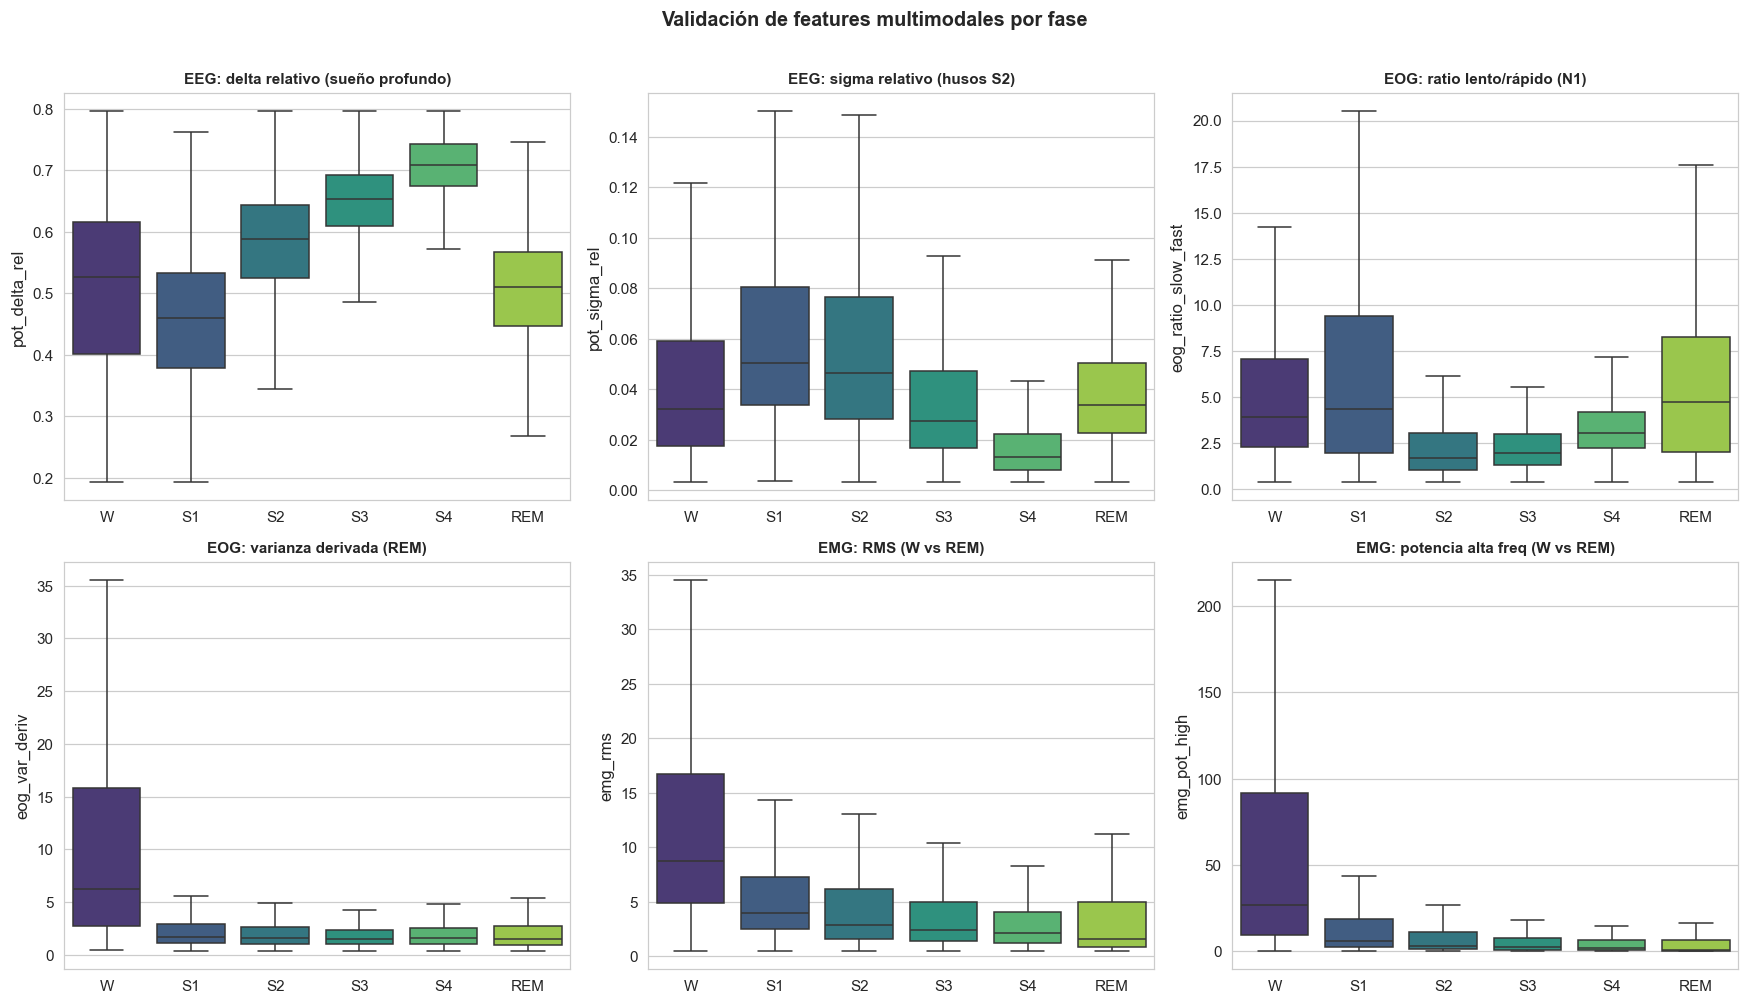

In [12]:
# Visualización
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (col, titulo) in zip(axes.flat, features_clave.items()):
    if col not in dataset.columns:
        ax.set_visible(False); continue
    valores = dataset[[col,'stage']].dropna()
    if len(valores)==0:
        ax.set_visible(False); continue
    # Clip 1-99%
    q1, q99 = valores[col].quantile([0.01, 0.99])
    valores = valores[(valores[col]>=q1) & (valores[col]<=q99)]
    sns.boxplot(data=valores, x='stage', y=col, order=CLASES_RK,
                ax=ax, showfliers=False, palette='viridis', linewidth=1)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Validación de features multimodales por fase',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'validacion_multimodal.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 8. Exportación

Guardamos el dataset consolidado con el mismo nombre que la v1 (para
que los notebooks 2 y HMM lo consuman sin cambios) pero conservando
también el largo para análisis exploratorios.

> **Importante:** el archivo `caracteristicas_fases_30s.csv` se
> sobrescribe con la versión v2. Si quieres conservar ambas versiones,
> renombra antes el original.

In [13]:
# Backup de la versión v1 si existe
v1_path = FEATURES_DIR / 'caracteristicas_fases_30s.csv'
if v1_path.exists():
    backup = FEATURES_DIR / 'caracteristicas_fases_30s_v1_solo_eeg.csv'
    if not backup.exists():
        import shutil
        shutil.copy(v1_path, backup)
        print(f'Backup de v1 guardado en: {backup.name}')

# Reordenar columnas: meta primero, después EEG, EOG, EMG
META = ['patient','epoch_idx','onset_s','stage']
cols_eeg_f = [c for c in dataset.columns if c not in META
              and not c.startswith('eog_') and not c.startswith('emg_')]
cols_eog_f = [c for c in dataset.columns if c.startswith('eog_')]
cols_emg_f = [c for c in dataset.columns if c.startswith('emg_')]
orden = META + cols_eeg_f + cols_eog_f + cols_emg_f
dataset = dataset[orden]

# Guardar
dataset.to_csv(v1_path, index=False)
dataset_largo.to_csv(FEATURES_DIR / 'caracteristicas_largo_v2.csv', index=False)

# Metadata
meta = pd.DataFrame([
    ('patient',   'Identificador del paciente'),
    ('epoch_idx', 'Índice de la época dentro del hipnograma'),
    ('onset_s',   'Inicio de la época en segundos'),
    ('stage',     'ETIQUETA: fase R&K {W,S1,S2,S3,S4,REM}'),
] + [(c, f'EEG: {c}') for c in cols_eeg_f]
  + [(c, f'EOG: {c}') for c in cols_eog_f]
  + [(c, f'EMG: {c}') for c in cols_emg_f],
    columns=['columna','descripcion'])
meta.to_csv(FEATURES_DIR / 'metadata_fases_v2.csv', index=False)

print(f'\n✅ Dataset v2 guardado: {v1_path}')
print(f'   {dataset.shape[0]:,} filas × {dataset.shape[1]} columnas')
print(f'   Features: {len(cols_eeg_f)} EEG + {len(cols_eog_f)} EOG + '
      f'{len(cols_emg_f)} EMG = {len(cols_eeg_f)+len(cols_eog_f)+len(cols_emg_f)} total')

print(f'\nArchivos en {FEATURES_DIR}:')
for f in sorted(FEATURES_DIR.glob('*')):
    print(f'  {f.name:<45} {f.stat().st_size/1024:>9.1f} KB')

Backup de v1 guardado en: caracteristicas_fases_30s_v1_solo_eeg.csv

✅ Dataset v2 guardado: D:\Repos\RAHBFDP-2026\notebooks\..\data\features_fases\caracteristicas_fases_30s.csv
   101,404 filas × 55 columnas
   Features: 32 EEG + 10 EOG + 9 EMG = 51 total

Archivos en D:\Repos\RAHBFDP-2026\notebooks\..\data\features_fases:
  caracteristicas_fases_30s.csv                   92826.0 KB
  caracteristicas_fases_30s_v1_solo_eeg.csv      121513.9 KB
  caracteristicas_largo_v2.csv                   174873.9 KB
  caracteristicas_por_fase.png                       92.2 KB
  metadata_fases.csv                                  0.3 KB
  metadata_fases_v2.csv                               1.6 KB
  perfil_bandas_por_fase.png                         41.8 KB
  validacion_multimodal.png                         120.4 KB


## 9. Resumen y siguiente paso

### Lo que produjo este notebook

- Un dataset enriquecido con **EEG + EOG + EMG**: típicamente 30+
  features adicionales sobre la versión solo-EEG.
- Pacientes sin alguna modalidad quedan con `NaN` en esas columnas;
  el notebook de modelado los maneja con imputación por mediana.
- Backup automático de la v1 para no perder el dataset original.

### Compatibilidad con el resto del pipeline

El archivo `caracteristicas_fases_30s.csv` mantiene la misma
estructura básica (`patient`, `epoch_idx`, `onset_s`, `stage` + features).
**Los notebooks de modelado y HMM funcionan sin cambios** — leen el
mismo archivo y procesan todas las columnas de features.

### Lo que esperar al reejecutar el modelado

| Métrica | v1 (32 features EEG) | v2 (EEG+EOG+EMG) esperado |
|---|---|---|
| κ AASM (Random Forest) | 0.62 | 0.68 – 0.72 |
| Recall N1 | 0.11 | 0.25 – 0.35 |
| Recall REM | 0.65 | 0.75 – 0.82 |
| Features más importantes | EEG espectrales | **EEG espectrales + eog_var_deriv + emg_rms** |

Cuando reejecutes el notebook 2 con el dataset v2, debería aparecer
`emg_rms` y `eog_var_deriv` o `eog_ratio_slow_fast` entre las top-15
features. Si **no** aparecen, indica que el modelo no está
aprovechando las modalidades adicionales (revisa que las columnas no
están todas NaN por algún problema de cobertura).

### Combinando con HMM

Si después de reejecutar con v2 obtienes $\kappa = 0{,}68$, aplicar
el HMM (notebook 3) probablemente lleve a $\kappa \approx 0{,}72{-}0{,}75$.
**Esto pondría tus resultados a la altura de deep learning sobre el
mismo dataset, pero con interpretabilidad clínica completa**.